ENGS 106 - Final Project
Authors - Taka Khoo, Doruk, Harry Leiter

<small>

    Overall design:

        typedef struct {
            image
            label
        } sample_t


        training(){
            init_network()
            sample = load_datapoint
            output = feedforward(sample->png)
            tocompare = getbackpropdata(sample)
            backprop(output, tocompare)
        }




        gettrainingdata(sample_t sample){
            Case (sample->label):
                1:
                    upscaledimg = upscale(sample->image)
                    gaussian = gaussian(upscaledimg)
                    harmonics = harmonics(gaussian, sample->fundamental_note_for_A_in_hertz)
                    harmonics_smear = gaussian(harmonics)
                    smooth = smooth(harmonics_smear)
                    return trainingcomparison       
                2:
                .
                .
                .
        
        }

</small>

# Below this markdown are an idea of the functions we could use to condition our data for the purposes of comparison during training

and here is my thinking behind these functions

<small> Create neural network Structure
    - inputs will be numbers 0-7 of mnist dataset (pictures of handwritten digits from 0-7)
        -These inputs will represent the notes of the major scale
    - output
        *Image of a spectrogram
            *Want to look like the input image? (maybe this would allow for more creative experimentation with finalized model than just looking like a letter)
            
            *Image is square, so we would want the output to be square as well
                -I'm not sure what to use for the image (spectrogram resolution):
                    Guessing around 1024x1024
                    
                    ~Training on 1024x1024 input images would probably be too resource intensive, so we might want to
                     upscale input image and then compare to that

                    *maybe drop down to 1008 for easier upscaling (mnist - 24x24 -- 24*36 = 1008 {24*4*3*3} -- esrgan upscaler works in factors of 1,2,3,4 )

            *We could compare the images with readily available tools online

            *In natural musical instruments, harmonics typically die out the further one gets from the fundamental note. Maybe we can
             achieve this by applying a horizontal gaussian filter to the output, and using that to determine loss as well
</small>

In [4]:
# Install the pinned environment before opening this notebook. No packages are installed by executing cells.
# CPU baseline: pip install -r requirements-cpu.txt
# Historical notebook extras: pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/pvigier/perlin-numpy to /tmp/pip-req-build-xhmua39j
  Running command git clone --filter=blob:none --quiet https://github.com/pvigier/perlin-numpy /tmp/pip-req-build-xhmua39j
  Resolved https://github.com/pvigier/perlin-numpy to commit 5e26837db14042e51166eb6cad4c0df2c1907016
  Preparing metadata (setup.py) ..

In [5]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import gaussian_filter
from scipy.stats import norm
from PIL import Image
import matplotlib.pyplot as plt

* Upscaler:

In [6]:
import cv2

from scipy.signal import resample

def upscale(input):
    """
    Upscale the input image to 1008x1008 using SciPy's resample function.
    """
    img = cv2.imread(f"{input}.jpg", cv2.IMREAD_GRAYSCALE)
    # Resample rows first, then columns:
    upscaled_rows = resample(img, 1008, axis=0)
    upscaled = resample(upscaled_rows, 1008, axis=1)
    cv2.imwrite(f"{input}.png", upscaled)




* Gaussian function:

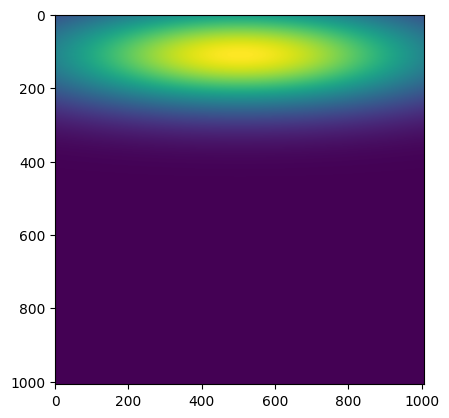

In [7]:
'''
                        1-D gaussian smearing
                        
'''
def gaussian1d(image, sigma, axis):

    blurred = gaussian_filter1d(image, sigma=sigma, axis=axis)
    return blurred
'''
                        2-D gaussian smearing
'''
def gaussian2d(image, sigma):
    image = gaussian_filter(image, sigma = sigma)
    return image
'''
                        Applies gaussian filter across entire image
                            * Doesnt smear, multiplies input by the filter directly
'''

def gaussianfilter(image, sigma, mu, fade):
      
    for row in range(image.shape[1]):
        #get pdf values for the row, multiply them by img
        image[row, :] = norm(loc = mu, scale = sigma).pdf(row) * image[row, :]
    for col in range(image.shape[1]):
        image[:, col] = norm(loc = 504, scale = fade).pdf(col) * image[:, col]
    return image

test = np.full((1008, 1008), 255).astype(np.float64)
test = gaussianfilter(test, 100, 110, 400)
test= test / test.max()
plt.imshow(test)
plt.show()

* Frequency Selector:

In [8]:
'''
                            This function selects only desired frequencies base on fundamental note

                            We could also use this function to extract whatever frequencies we want to keep at whatever time
'''
def get_fundamental_frequency(label):

    if (label == 18):
        freq = int(round(27.5 * 2 ** (11/12.0)))
    elif (label == 14):
        freq = int(round(27.5 * 2 ** (12/12.0)))
    else:
        freq = int(round(27.5 * 2 ** (label/12.0)))
    
    return freq

#Need to take care of S and E

def freq_selection(gaussian, fundamentalnote):
    from digit_audio import select_harmonics
    # Rows represent 1 Hz in the historical 1008-row additive-synthesis grid.
    return select_harmonics(gaussian, fundamentalnote)


* Perlin Noise:

7.863843544416726
255.0


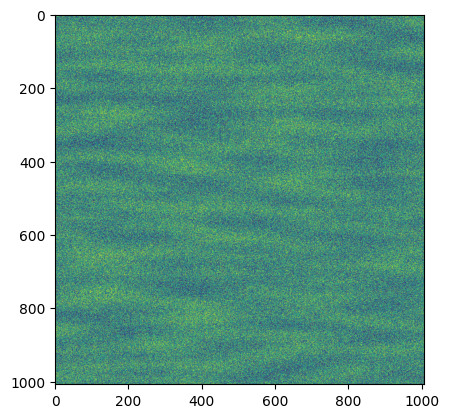

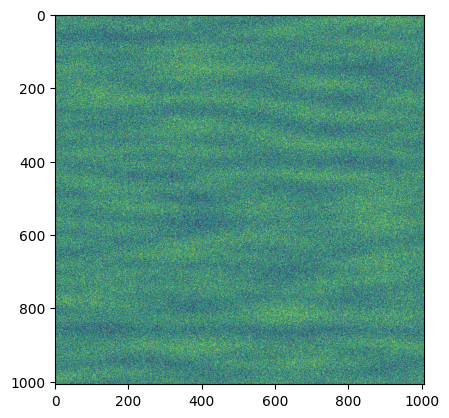

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from perlin_numpy import (generate_perlin_noise_2d, generate_fractal_noise_2d
)

def perlin_2d(input, noisex, noisey, fuzz, dilution):
    noise = generate_perlin_noise_2d(input.shape, (noisey, noisex))

    offset = np.full((1008, 1008), dilution).astype(np.float64) + (np.random.rand(1008, 1008))*fuzz
    
    noise = noise + offset

    noise = noise / noise.max()    

    input = input * noise

    return input

def perlin_2d_filter(shape_, scale, noisex, noisey, fuzz, dilution):
    noise = generate_perlin_noise_2d(shape_.shape, (noisey, noisex))

    offset = np.full((1008, 1008), dilution).astype(np.float64) + (np.random.rand(1008, 1008))*fuzz
    
    noise = noise + offset

    noise = (noise / noise.max()) * scale

    return noise

test = np.full((1008, 1008), 255).astype(np.float64)
filter = perlin_2d_filter(test, 1, 4, 24, 7, 1)
test = perlin_2d(test, 4, 24, 7, 1)
print(test.min())
print(test.max())
plt.imshow(test)
plt.show()
plt.imshow(filter)
plt.show()

Convert Spectrogram to wav:

In [10]:
import numpy as np
from digit_audio import write_audio

def convert_to_wav(spectrogram, output, duration):
    # Stream rows into one waveform, with explicit Hz and deterministic phase.
    # Silence remains zero instead of dividing by its peak.
    write_audio(output, np.maximum(spectrogram, 0), np.arange(spectrogram.shape[0]),
                duration=duration, sample_rate=44100, seed=7)


In [11]:
#ripped from geeksforgeeks

import cv2
from skimage.metrics import structural_similarity as ssim
# Function to calculate SSIM
def calculate_ssim(imageA, imageB):
    # Convert images to grayscale
    grayA = cv2.cvtColor(imageA, cv2.COLOR_BGR2GRAY)
    grayB = cv2.cvtColor(imageB, cv2.COLOR_BGR2GRAY)
    
    # Compute SSIM between the two images
    score, _ = ssim(grayA, grayB, full=True)
    return score

imageA = cv2.imread('thenumber4-upscaled-blurred-harmonics-smeared-smoothed.png')
imageB = cv2.imread('thenumber5-upscaled-blurred-harmonics-smeared-smoothed.png')

ssim_score = calculate_ssim(imageA, imageB)
print(f"SSIM score: {ssim_score}")

SSIM score: 0.8995857851385594


[ WARN:0@1.502] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


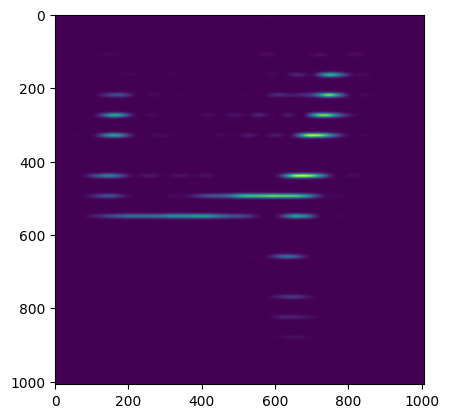

(1008, 44100)


IndexError: list index out of range

In [12]:
import cv2
'''
Main Processing Loop for Inputs
                                            Passing 4 and 5 through gaussian
'''

inputs = ['thenumber4', 'thenumber5']

#note to assign for inputs
fundamental_note = 110
#center of y-direction filter
mu = fundamental_note * 1
#y-direction filter sd
sigma = 300
#track fades in and out
fade_inout = 250
#smear x
smear_x = 10
#smear y
smear_y = 4
#x and y smoothing
smooth_xy = 1
#duration of track
duration = 1

##NOISE APPLIED TO OUTPUT
#Perlin noise constants for x and y
pnoisex = 12
pnoisey = 24
#Adds static fuzz to spectrogram
fuzz = 0
#Waters down perlin noise
dilution = 3

##NOISE OVERLAID
scale = 0 # Set 0 to disable
pnoisex2 = 1
pnoisey2 = 1
fuzz2 = 0
dilution2 = 40

 #Processing each input file
for i in inputs:
    upscale(f'{i}')

    #Gaussian Filter
    im2array = cv2.imread(f'{i}.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)
    filtered = gaussianfilter(im2array, sigma, mu, fade_inout)
    curr = filtered

    #Harmonics etc
    harmonic = freq_selection(curr, fundamental_note)
    curr = harmonic

    #y-axis gaussian smear
    y_gaussian = gaussian1d(curr, smear_y, 0)
    curr = y_gaussian
    curr = (curr - curr.min()) / (curr.max() - curr.min()) * 255

    #x-axis gaussian smear
    x_gaussian = gaussian1d(curr, smear_x, 1)
    curr = x_gaussian
    curr = (curr - curr.min()) / (curr.max() - curr.min()) * 255

    #smoothing (2-D gaussian)
    smoothed = gaussian2d(curr, smooth_xy)
    curr = smoothed
    curr = (curr - curr.min()) / (curr.max() - curr.min()) * 255

    #perlin-noise
    perlin = perlin_2d(curr, pnoisex, pnoisey, fuzz, dilution)
    curr = perlin
    curr = (curr - curr.min()) / (curr.max() - curr.min()) * 255

    #noise overlay
    overlay = perlin_2d_filter(curr, scale, pnoisex2, pnoisey2, fuzz2, dilution2)
    curr = curr + overlay

    plt.imshow(curr)
    plt.show()

    #convert to wav file
    convert_to_wav(curr, f'{i}-out.wav', duration)

    #save image for comparison
    Image.fromarray(curr).convert('RGB').save(f'{i}-out.png')

#compare images
imageA = cv2.imread(f'{inputs[0]}-out.png')
imageB = cv2.imread(f'{inputs[1]}-out.png')

ssim_score = calculate_ssim(imageA, imageB)
print(f"SSIM score: {ssim_score}")
    


Network Design Notes

1. Input & Output

	Input X: 
		-Low Res image MNIST 
		-X ∈ R^(H_in x W_in x C)
		-H_in, W_in = height and widfth (28), C=1 for greyscale

	Output Y:
		-High Res Spectrogram that visually encodes desired harmonic stuff (fundamental, 1.25f, 1.5f)
		-Target Image size if 1008x1008
		-Y ∈ R^(H_out x W_out x 1)
		-Generated by processing functions (upscaling, Gaussian filtering, frequency selection, Perlin noise, etc.) that imprint the desired fundamental note and its harmonics (keeping only rows corresponding to f, 1.25f, 1.5f)

2. Mapping Digit to Musical Note

	0 → A
	1 → A#
	2 → B
	3 → C
	4 → C#
	5 → D
	6 → D#
	7 → E
	8 → F
	9 → F#
	S → G
	E → G#
	When generating the target spectrogram Y for a given sample, the processing pipeine uses a parameter (assigned fundamental frequency f0) in the frequency selection function. 
	That function sets pixel values only at rows corresponding to f0, 1.25f0, 1.5f0.
	Target Y embeds the harmonic structure of the note

3. Neural network Archistecture

	Encoder-Decoder (aka U-Net) Architecture
		-Encoder Learns a latent representation of the digit
		-Decoder upsamples and transforms that latent code into the desired spectrogram
	
	Encoder:
		Input: X ∈ R^(H_in x W_in x C)

		Convolution Layers: Apply several convolutional layers with nonlinear activations (ReLU?) to extract features.
			ex Layer: h1 = ReLU(W1 * X + b1)
			-W1 = set of learnable filters
			- * = convolution
			-b1 = bias

		Downsampling: Either using strided convolutions or pooling, reduce the spatial dimensions to form a latent representation z ∈ R^(H_z x W_z x D)
			-H_z, W_z << H_in, W_in
			-D = # of feature maps
	Decoder:
		Upsampling: Decoder used transposed convolutions (or upsampling folloed by convolution) to increase the spatial resolution of z until we reach H-out x W_out (1008x1008)
			Y' = ReLU(Wd *' bd)
			-*' = transposed convolution
		
		Skip Connections: To preserve spatial details, can use skip connections to copy features from encoder layers to corresponding decoder layers

		Output Layer: Final Layer outputs a single channel image using a convolution with a sigmoid or tanh activation to produce values in a desired range, either [0,1] or [-1,1]
	
	Math:
		Let f_θ denote the NN mapping, with parameters θ. 
			Forward Pass: Y_hat = f_θ(X), where Y_hat is the predicted spectrogram image

		**Loss Function: Still need to figure out structural way to do this, but for now, here is the pixel-wise MSE Loss way equation: 
		L(θ) = ||Y_hat - Y||^2

		Backpropagation: Using Gradient Descent (or Adam), we update the parameters:
			θ <- θ - η * ∇_θ * L(θ), where η = LR

4. Upscaler Component
	Very intense to train directly on 1008x1008 images, want to train network on a lower-res version/downscaled version of spectrogram
	We use a pre-trained ESRGAN upscaler to increase the resolution of the network output; this way we focus on the mapping itself first and then we can engance the resolution with the dedicated upscaler

Extra Math:
Convolution: For an input X and a filter W of size kxk, the convolution pixel (i,j) is
	(Y)ij = (Sum m=1->k)(Sum n=1 -> k)W_m,n * X_i+m-1, j+n-1 + b

Transposed Convolution: Inverse of Convolution, spreads each pixel of the latent representation into a arger region. Gradient of convolution w.r.t. its input

Loss Function (MSE):
	1/n * (Sum i=1 -> n) (Y_hat_i - Y-i)^2, where N = total # of pixels in output image

Gradient Descent Update:
	θ <- θ - η(Partial ∂L/∂θ)

Workflow Plan:

1. Data Prep: Use Processing functions to generate target spectrogram Y w/ fundamental note
2. NN Training: Input X is fed into encoder decoder network fθ to produce Y_hat, compute the loss, backpropogate the loss and update parameters with GD
3. Inference: At test time, given a new Digit X, the network outputs a spectrogram Y_hat, output is upscaled, 

In [254]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
from torch.utils.data import Dataset

#Encoder/Decoder


import torch
import torch.nn as nn

class SpectrogramGenerator(nn.Module):
    def __init__(self):
        super(SpectrogramGenerator, self).__init__()
        # Encoder Stage 1 (split)
        self.encode1_conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.encode1_pool = nn.MaxPool2d(2)  # (64, 28, 28) -> (64, 14, 14)
        
        # Encoder Stage 2 (split)
        self.encode2_conv = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.encode2_pool = nn.MaxPool2d(2)  # (128, 14, 14) -> (128, 7, 7)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Decoder with skip connections
        self.upsample2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # (256,7,7) -> (128,14,14)
        self.decode2 = nn.Sequential(
            nn.Conv2d(128 + 128, 128, kernel_size=3, padding=1),  # concat upsample_2 with encode2_conv
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upsample1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)   # (128,14,14) -> (64,28,28)
        self.decode1 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),  # concat upsample_1 with encode1_conv
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Final upsampling and output layer
        self.upsamplefinal = nn.Upsample(size=(1008, 1008), mode='bilinear', align_corners=False)
        self.finalconv = nn.Conv2d(64, 1, kernel_size=3, padding=1)
        self.finalact = nn.LeakyReLU()

    def forward(self, x):
        # Encoder Stage 1
        encode1_conv = self.encode1_conv(x)           # (64, 28, 28)
        encode1 = self.encode1_pool(encode1_conv)       # (64, 14, 14)
        # Encoder Stage 2
        encode2_conv = self.encode2_conv(encode1)        # (128, 14, 14)
        encode2 = self.encode2_pool(encode2_conv)        # (128, 7, 7)
        # Bottleneck
        bottle_neck = self.bottleneck(encode2)           # (256, 7, 7)
        # Decoder stage 2 with skip from encode2_conv
        upsample_2 = self.upsample2(bottle_neck)         # (128, 14, 14)
        concat_2 = torch.cat([upsample_2, encode2_conv], dim=1)  # (256, 14, 14)
        decode_2 = self.decode2(concat_2)                # (128, 14, 14)
        # Decoder stage 1 with skip from encode1_conv
        upsample_1 = self.upsample1(decode_2)            # (64, 28, 28)
        concat_1 = torch.cat([upsample_1, encode1_conv], dim=1)  # (128, 28, 28)
        decode_1 = self.decode1(concat_1)                # (64, 28, 28)
        # Final upsampling and output
        upsampled = self.upsamplefinal(decode_1)         # (64, 1008, 1008)
        out = self.finalconv(upsampled)
        return self.finalact(out)

class SpectrogramDataset(Dataset):
	def __init__(self, root='./data', split="byclass", filter_labels=None, transform=None):
		self.transform = transforms.ToTensor()
		self.base_dataset = torchvision.datasets.EMNIST(
			root=root, train=True, split=split, download=True, transform=self.transform
		)
		self.filter_labels = filter_labels
		self.indices = [i for i, (_, label) in enumerate(self.base_dataset) if label in filter_labels]

	def __len__(self):
		return len(self.indices)

	def __getitem__(self, idx):
		actual_idx = self.indices[idx]
		img, label = self.base_dataset[actual_idx]
		img = img.transpose(1, 2)  # Transpose the image tensor
		# Convert image tensor to numpy array and scale to [0, 255]
		digit_img = img.squeeze().numpy() * 255
		# Generate the spectrogram target based on image and label
		target_np = generate_target_spectrogram(digit_img, float(label))
		# Normalize target to [0,1]
		target_np = (target_np - target_np.min()) / (target_np.max() - target_np.min() + 1e-8)
		target_tensor = torch.from_numpy(target_np).unsqueeze(0).float()
		return img, target_tensor
	


"""
We next need a target generation function, 
which will need to call the full processing pipeline with all of our 
functions we wrote earlier and based on the label

1. Save the input digit image numpy array with values 0-255 to disk as a temporary JPEG.
2. Call the upscaler function to upscale the image.
3. Load the upscaled image.
4. Apply a Gaussian filter (using gaussianfilter) to weight the image.
5. Apply frequency selection (freq_selection) using the fundamental note determined
by the digit label from exponential music equation f=110 * 2^(label/12)
6. Apply y-axis Gaussian smear (gaussian1d) then normalize.
7. Apply x-axis Gaussian smear (gaussian1d) then normalize.
8. Apply 2-D Gaussian smoothing (gaussian2d) then normalize.
9. Add Perlin noise using perlin_2d, normalize.
10. (Can Change, dont need, 0 if want disable) overlay additional noise via perlin_2d_filter.
11. Normalize the final output to the range 0-255 and return it.
"""
import os
import time
import tempfile
from PIL import Image
import cv2
import numpy as np

def generate_target_spectrogram(digit_image, label):
    # 1. Create a unique temporary file for the input image
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
        temp_jpg = tmp.name
    Image.fromarray(digit_image.astype(np.uint8)).convert('RGB').save(temp_jpg)
    
    # 2. Prepare a base name and corresponding output PNG name.
    base_name = os.path.splitext(temp_jpg)[0]  # remove extension
    temp_png = base_name + ".png"
    
    # 3. Call upscale using the unique base name (assumes upscale() uses base_name).
    upscale(base_name)
    
    # 4. Wait (up to 5 sec) for the output file to appear.
    timeout = 5.0
    start_time = time.time()
    while not os.path.exists(temp_png):
        time.sleep(0.1)
        if time.time() - start_time > timeout:
            raise TimeoutError(f"Upscale did not produce file {temp_png}")
    
    # 5. Read the upscaled image.
    upscaled = cv2.imread(temp_png, cv2.IMREAD_GRAYSCALE)
    if upscaled is None:
        raise ValueError(f"Failed to read upscaled image from {temp_png}")
    upscaled = upscaled.astype(np.float32)
    
    # 6. Continue with your processing...
    sigma_val = 400
    mu_val = 110
    fade_val = 250
    filtered = gaussianfilter(upscaled, sigma_val, mu_val, fade_val)
    
    fundamental_note = get_fundamental_frequency(label)
    harmonic = freq_selection(filtered, fundamental_note)
    
    smear_y = 2
    y_smeared = gaussian1d(harmonic, smear_y, 0)
    y_smeared = (y_smeared - y_smeared.min()) / (y_smeared.max() - y_smeared.min() + 1E-8) * 255
    
    smear_x = 20
    x_smeared = gaussian1d(y_smeared, smear_x, 1)
    x_smeared = (x_smeared - x_smeared.min()) / (x_smeared.max() - x_smeared.min() + 1E-8) * 255
    
    smooth_xy = 0
    smoothed = gaussian2d(x_smeared, smooth_xy)
    smoothed = (smoothed - smoothed.min()) / (smoothed.max() - smoothed.min() + 1E-8) * 255
    
    pnoisex = 24
    pnoisey = 24
    fuzz = 0
    dilution = 20
    perlin_img = perlin_2d(smoothed, pnoisex, pnoisey, fuzz, dilution)
    perlin_img = (perlin_img - perlin_img.min()) / (perlin_img.max() - perlin_img.min() + 1E-8) * 255
    
    scale_val = 0
    pnoisex2 = 2
    pnoisey2 = 24
    fuzz2 = 0
    dilution2 = 20
    overlay = perlin_2d_filter(perlin_img, scale_val, pnoisex2, pnoisey2, fuzz2, dilution2)
    final_img = perlin_img + overlay
    
    final_img = (final_img - final_img.min()) / (final_img.max() - final_img.min() + 1E-8)
    
    # 7. Clean up temporary files.
    os.remove(temp_jpg)
    os.remove(temp_png)
    
    return final_img

In [255]:
# Install pytorch-msssim through requirements.txt before running the notebook.


Note: you may need to restart the kernel to use updated packages.


We will now execute the training loop, using MNIST as the dataset 

Training interrupted! Model saved to U-Net_checkpoint_step_1_INTERRUPTED.pth
Final loss history saved.


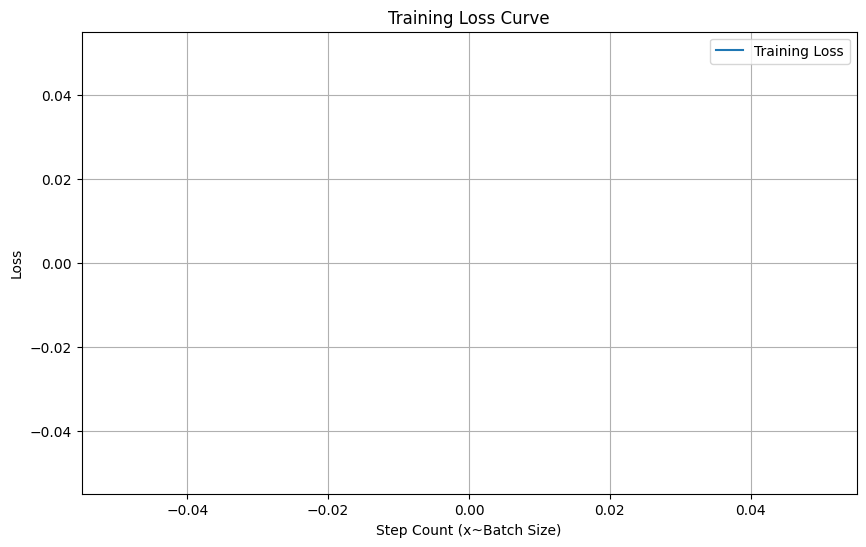

NN Training Complete!


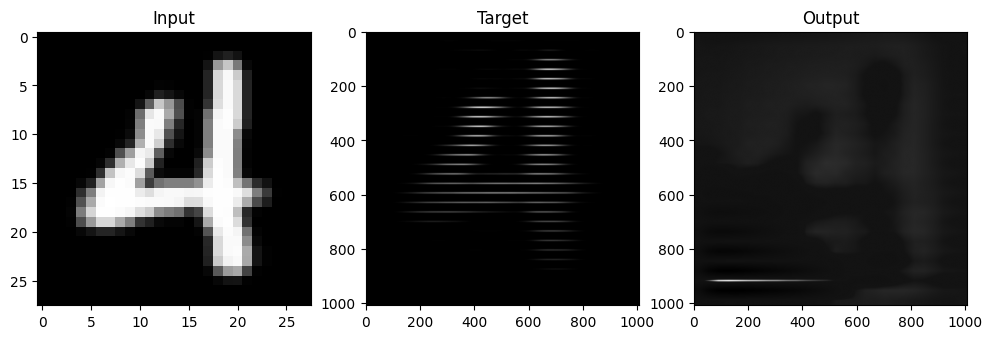

Step Count: 4914, Batch Loss: 494.5616
Huber Loss: 0.0039, SSIM Loss: 0.4086, Frequency Loss: 4944.3667
Training interrupted! Model saved to U-Net_checkpoint_step_4915_INTERRUPTED.pth
Final loss history saved.


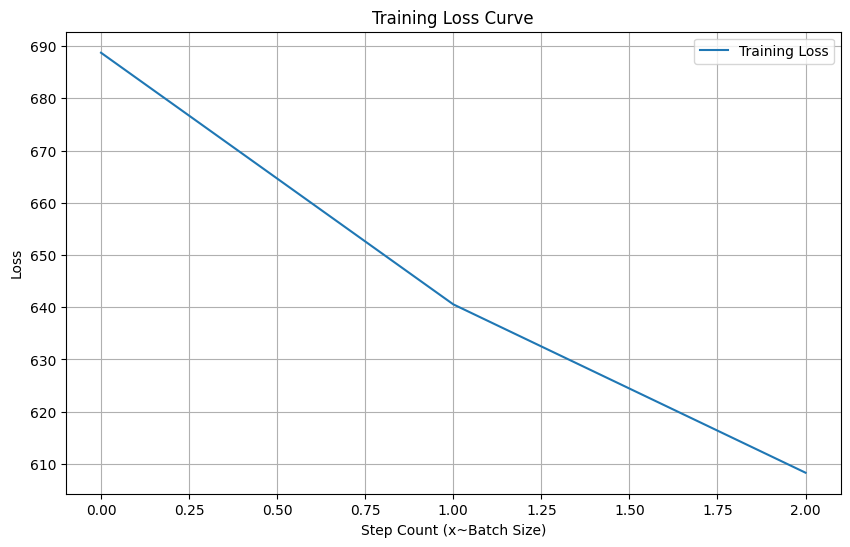

NN Training Complete!


In [ ]:
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.optim as optim
import torch.cuda.amp as amp
import matplotlib.pyplot as plt
from pytorch_msssim import ms_ssim
import torch.backends.cudnn as cudnn
import numpy as np

# Enable cudnn benchmark for speed if input sizes are constant
random.seed(7)
np.random.seed(7)
torch.manual_seed(7)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(7)
cudnn.benchmark = False
cudnn.deterministic = True
cudnn.enabled = True

plt.ion()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")
step_count = 0
fast_dev_run = os.getenv("UNET_FAST_DEV_RUN") == "1"
batchsize = 1 if fast_dev_run else 24
losses = []

def frequency_loss(output, target):
    # Example using L2 on magnitude spectra
    output_fft = torch.fft.rfft2(output)
    target_fft = torch.fft.rfft2(target)
    return torch.mean((torch.abs(output_fft) - torch.abs(target_fft)) ** 2)

# Use the custom dataset (assumed to be defined elsewhere)
filter_labels = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 18, 14}
train_dataset = SpectrogramDataset(root='./data', split="byclass", filter_labels=filter_labels)
if fast_dev_run:
    train_dataset = torch.utils.data.Subset(train_dataset, range(min(2, len(train_dataset))))
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batchsize,
    shuffle=True,
    num_workers=0
)

# Initialize the model (randomly initialized weights)
model = SpectrogramGenerator()
criterion_huber = nn.HuberLoss(delta=1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

model = model.to(device)

num_epochs = 1 if fast_dev_run else 10

try:
    for epoch in range(num_epochs):
        running_loss = 0.0
        model.train()
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                outputs = model(inputs)
                # Compute individual loss terms
                huber_loss_val = criterion_huber(outputs, targets)
                freq_loss_val = frequency_loss(outputs.float(), targets.float())
                ssim_loss_val = 1 - ms_ssim(
                    outputs, targets, data_range=1.0, size_average=True,
                    weights=(0.1, 0.15, 0.2, 0.2, 0.2)
                )

            # Combine losses into one final loss
            loss = 0.65 * huber_loss_val + 0.34 * ssim_loss_val + 0.0001 * freq_loss_val
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            step_count += inputs.size(0)
            losses.append(loss.item())

            if step_count % (batchsize * 1) == 0:
                clear_output(wait=True)
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(inputs[0].detach().cpu().squeeze().numpy(), cmap='gray')
                axs[0].set_title("Input")
                axs[1].imshow(targets[0].detach().cpu().squeeze().numpy(), cmap='gray')
                axs[1].set_title("Target")
                axs[2].imshow(outputs[0].detach().cpu().squeeze().numpy(), cmap='gray')
                axs[2].set_title("Output")
                plt.show()

                print(f"Step Count: {step_count}, Batch Loss: {loss.item():.4f}")
                # Print the individual loss components
                print(f"Huber Loss: {huber_loss_val.item():.4f}, "
                      f"SSIM Loss: {ssim_loss_val.item():.4f}, "
                      f"Frequency Loss: {freq_loss_val.item():.4f}")

            if step_count % (batchsize * 500) == 0:
                checkpoint_path = f"U-Net_2_step_{step_count+1}.pth"
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'step_count': step_count
                }, checkpoint_path)
                print(f"Model checkpoint saved to {checkpoint_path}")
                steps_loss = running_loss / ((batch_idx + 1) * batchsize)
                # Per-batch losses are already recorded above.

except KeyboardInterrupt:
    checkpoint_path = f"U-Net_2_{step_count+1}_INTERRUPTED.pth"
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'step_count': step_count
    }, checkpoint_path)
    print(f"Training interrupted! Model saved to {checkpoint_path}")
    np.save("U-Net-Two_INTERRUPTED.npy", np.array(losses))

np.save("U-Net-Two.npy", np.array(losses))
print("Final loss history saved.")

plt.figure(figsize=(10, 6))
plt.plot(losses, label='Training Loss')
plt.xlabel('Step Count (x~Batch Size)')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


print("NN Training Complete!")


At 10017 steps, I noticed that the loss value was very low, even though the output hardly contained any of the frequency lines that we are trying to get, so at this point, I added ms_ssim loss to the loss function with a ratio of ms_ssim/mse of 7/3



ms_ssim was successful in allowing the model to learn to begin approximating the vertical bands. However, the bands are very blocky, likely because they are structurally similar. now that there are some vertical lines, i decided to decrease significance of ssim to capture finer details, setting ratio to 1/1

contrary to expectations, setting the ratio to 1 led to the outputs becoming a bit more blurred. Instead, I will try changing ratio back to 7/3 while decreasing the window size of the ms_ssim to try to emphasize smaller details. Additionally, more vertical features appear to be learning more slowly (e.g. the number 1 looks worse than 6 or 7) so i am adding a scaling factor to the ssim dependent on the normal input as well as the transposed input. In addition to this, I will scale the ssim factor relative to mse so the ratio is more effectively applied

After I applied the above changes, I noticed a very low loss value, and scaled the ssim loss by 3 to directly increase its effect on weight updates

The above changes appeared to be working well, 

At 39000 steps, improvements have been minimal. Parts of the image have become sharper, but others have become cloudy. Overall, results have improvements have been minor. Some parts are working better, but many images now come out very dim. The parts of the imag which are correct appear better, but the incorrect parts have become very "cloudy"

I have added a fequency loss function which compares the fft of the output and target spectrogram. I will also remove the scaling factor on ssim loss because I don't know if that is causing instability in the outputs

Upon applying the above, the structural detail learned was lost quickly. I have decreased the scaling factor of the frequency loss to .005

After observing training and seeing minimal improvement, I have changed from MSE loss to L1 loss to discourage blurry outputs.

After 1000 steps, numbers like "1" have improved drastically in quality. Some artifacts have been introduced, but cloudy outputs have stopped almost altogether. Going to leave this to run for another 10k steps. Loss has also increased, which hopefully encourages better learning

Artifacts increasing. Trying again, this time with "huber" loss as was used earlier (back when we didnt include skips)

Tried several different variations. Overall, havent been able to get learning to improve compared to before adding the frequency loss. Eliminating frequency loss, keeping huber loss in place of MSE.

I am noticing around 44000 steps that the spectral lines are often not consistent with the labels - so number 3 might correspond to an A for example. I don't know if this has been the case the whole time, but I think it may not have been. I'll need to get frequency loss working by 50000 steps hopefully to address this. Overall, noticed minor improvements

I've noticed that the number five, three, and  few others produce wrong, but consistently wrong, outputs. So there's a pattern, but its the wrong pattern. Model is also not really improving. All of the difficulties I am having with further improvement suggest the model is stuck at a local minima. At 50000 steps, I will increase the learning rate to try to "bump" it out. I will also try to implement frequency loss effectively

Also, I have added a model save on keyboard interrupt so I can make more granular adjustments. I also added print statements for the different loss functions so they can be adjusted more appropriately

"bumping" the model did not work, just threw everything else and didnt stabilize quickly. I am going to try "curriculum learning" -- training only on the number five for awhile

Some improvements but 5 still isnt great, increasing learning rate to 5e-3

Still not overcoming error, increasing lr to 9e-3

Increased all the way to 15e-3, still not overcoming error

Trying to reintroduce other numbers

Reintroducing other numbers and training for a few hundred steps at 15e-3 seems to have knocked it out of the minima -- incorrect patterns have disappeared, at cost of overall accuracy
Lowered lr back down to 1e-3. At around 60000 steps now

Increased ssim error scale by 3 at about 70000 steps

removed scaling of ssim loss at 73000 steps. Output got a lot worse, but hopefully it will stabilize -- loss increased, so there is more to learn i guess..
Got a bit better, but output is similar to earlier outputs i got when freq loss was included. removing it at 75000 steps

Still no improvement at 80000 steps, i am going to try removing ssim loss completely

I guess its good at 100000 steps. im going to interrupt it, add ssim back in and go all in on frequency loss

Adding a substantive frequency loss has destroyed the output, but theres already a good enough output somewhere in the previous steps so YOLO (fallback is 94999)
It didnt work lol

Retrained model again starting from 60,001 steps up to about 150,000 steps. The output quality is essentially the same. Evidently the model is not learning beyond a certain amount

Finally, when we finish training, we can take a new digit img and pass it through the model and then convert the spectrogram to audio using the function we wrote

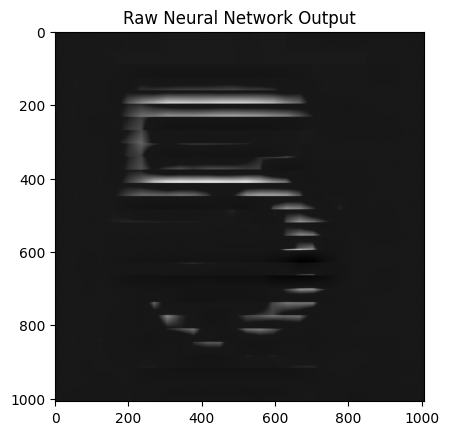

(1008, 44100)
Inference complete. Predicted spectrogram image and audio saved


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image





# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse the model trained above. An explicit checkpoint is opt-in, never automatic.
if os.getenv("UNET_CHECKPOINT"):
    model = SpectrogramGenerator()
    checkpoint_path = os.environ["UNET_CHECKPOINT"]
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    try:
        model.load_state_dict(checkpoint["model_state_dict"])
    except RuntimeError as exc:
        raise RuntimeError(
            "The historical checkpoint targets an earlier architecture; "
            "run with UNET_FAST_DEV_RUN=1 or retrain the current model."
        ) from exc
    model.to(device)
model.eval()

with torch.no_grad():
    # Read the image in grayscale
    sample_path = 'thenumber4-upscaled.png'
    sample_img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)  # shape: (H, W)
    if sample_img is None:
        raise ValueError(f"Could not read {sample_path}. Please check the file path.")
    
    # Resize to match the model's expected input size (28x28) since training images are 28x28
    sample_img = cv2.resize(sample_img, (28, 28))
    
    # Normalize image to [0,1] (as done by transforms.ToTensor() during training)
    sample_img = sample_img.astype(np.float32) / 255.0
    
    # Convert image to PyTorch tensor and add batch and channel dimensions -> shape (1, 1, 28, 28)
    sample_tensor = torch.from_numpy(sample_img).unsqueeze(0).unsqueeze(0).to(device)
    
    # Run inference: model input is a 28x28 digit; output will be a spectrogram of shape (1,1,1008,1008)
    output = model(sample_tensor)
    
    # Get the raw network output (without additional normalization)
    raw_output = output.squeeze().detach().cpu().numpy()  # shape: (1008, 1008)
    
    # Plot the raw network output for inspection
    plt.imshow(raw_output, cmap='gray')
    plt.title("Raw Neural Network Output")
    plt.show()
    
    # For saving and audio conversion, normalize the output to [0,255]
    predicted_np = (raw_output - raw_output.min()) / (raw_output.max() - raw_output.min() + 1e-8) * 255
    predicted_np = predicted_np.astype(np.uint8)
    
    # Save the spectrogram image
    Image.fromarray(predicted_np).convert('RGB').save('predicted_spectrogram.png')
    
    # Convert the normalized spectrogram to audio (ensure that convert_to_wav is defined)
    convert_to_wav(predicted_np, 'predicted_audio.wav', duration=1)
    print("Inference complete. Predicted spectrogram image and audio saved")


(0,)


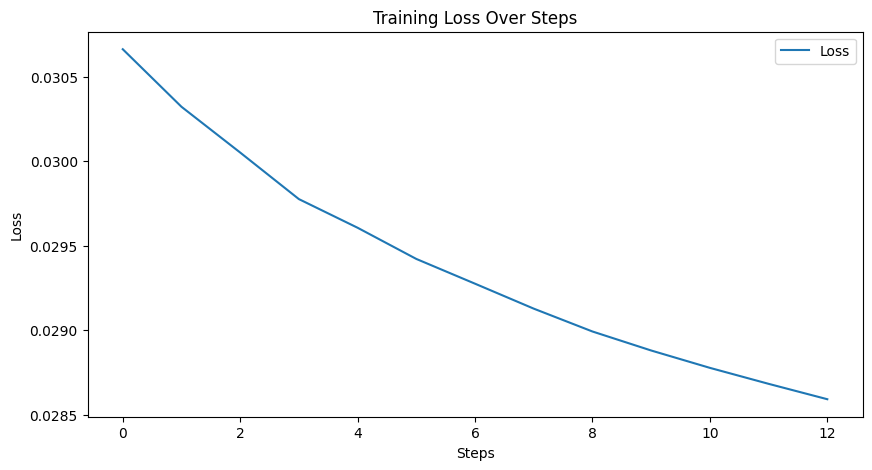

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot this run, not missing historical arrays from another architecture.
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(losses)+1), losses)
plt.xlabel('Optimizer update')
plt.ylabel('Training loss')
plt.title('Current run (not held-out performance)')
plt.grid(alpha=.3)
plt.show()
